In [1]:
import pandas as pd
import ray
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import plotly.graph_objects as go
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                    StratifiedKFold, StratifiedShuffleSplit,
                                    cross_val_score)
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, classification_report
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import joblib


2023-10-23 10:44:42.598088: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-23 10:44:42.787344: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-10-23 10:44:42.787372: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-10-23 10:44:42.788774: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-23 10:44:42.898196: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-23 10:44:42.899648: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [2]:
def optimize_hyperparameters(X, y):
    # Initialize a BalancedRandomForestClassifier
    clf = RandomForestRegressor()

    # Define hyperparameters grid
    param_grid = {
        'n_estimators': [200,500,800],
        'max_features': ['sqrt', 'log2'],
        'max_depth': [10, 20, 30, None]    }

    # Grid search with cross-validation
    grid_search = GridSearchCV(estimator=RandomForestRegressor(),
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',  # For regression
                           cv=3,  # Number of cross-validation folds
                           verbose=2,
                           n_jobs=-1  # Use all available CPUs
                          ) 
    grid_search.fit(X, y)

    # Return best parameters and best score
    return grid_search

In [98]:
def plot_regression_results(Y_true, Y_pred, metalicidad, title, path='/home/marcelo/nico/data_Splus_parameters/result/'):
    """
    Create subplots of true vs predicted values for all features and save them as a PDF.

    Parameters:
    - Y_true (DataFrame): Actual values.
    - Y_pred (DataFrame): Predicted values.
    - title (str): Title for the entire set of subplots.
    """
    
    num_columns = len(Y_pred.columns)
    
    # Check if there is only one column, and create a single plot
    if num_columns == 1:
        fig, ax = plt.subplots(figsize=(8, 6))
        sc = ax.scatter(Y_pred, Y_true, cmap='viridis', c=metalicidad.values, alpha=0.5)
        ax.plot([Y_true.min(), Y_true.max()],
                [Y_true.min(), Y_true.max()],
                color='red', linestyle='--')
        ax.set_xlim(Y_pred[Y_pred.columns[0]].values.min(),Y_pred[Y_pred.columns[0]].values.max())
      #  ax.set_title(Y_true)
        ax.set_xlabel(f'Predicted {Y_pred.columns[0]}')
        ax.set_ylabel(f'True {Y_pred.columns[0]}')
        ax.grid(True)
        fig.colorbar(sc, ax=ax)
    else:
        # Calculate the number of rows needed based on the number of columns
        nrows = -(-num_columns // 2)  # This is a way to compute the ceiling of the division.

        # Setting up a grid for the subplots
        fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 20))
        fig.suptitle(title, fontsize=16)

        # Flattening the axes array for easy indexing
        axes = axes.ravel()

        # Plot data for each column
        for idx, column in enumerate(Y_true.columns):
            # X-axis: Predicted values, Y-axis: True values
            sc = axes[idx].scatter(Y_pred[column], Y_true[column], cmap='viridis', c=metalicidad, alpha=0.5)

            # Diagonal line
            axes[idx].plot([Y_true[column].min(), Y_true[column].max()],
                           [Y_true[column].min(), Y_true[column].max()],
                           color='red', linestyle='--')

            # Set x-axis limits
            axes[idx].set_xlim(Y_pred[column].min(), Y_pred[column].max())
            axes[idx].set_title(column)
            axes[idx].set_xlabel(f'Predicted {column}')
            axes[idx].set_ylabel(f'True {column}')
            axes[idx].grid(True)
            fig.colorbar(sc, ax=axes[idx])

        # Remove any unused subplots
        for i in range(num_columns, nrows * 2):
            fig.delaxes(axes[i])
    
    # Save the figure to a PDF file
    fig.tight_layout()
    fig.subplots_adjust(top=0.95)
    fig.savefig(f'{path}{title}.pdf')






In [4]:
def preprocess_features(data,columns,bad_values):
    """
    Realiza el preprocesamiento de las características especificadas.

    Args:
    - data (pd.DataFrame): DataFrame original con los datos.

    Returns:
    - data (pd.DataFrame): DataFrame procesado con características adicionales y filas inválidas eliminadas.
    """
    
    # Busca valores 999 o -999 en las columnas especificadas
    invalid_values = data[columns].isin([bad_values, -bad_values]).sum()

    # Filtra y muestra solo las columnas que tienen estos valores inválidos
    columns_with_invalids = invalid_values[invalid_values > 0]

    if columns_with_invalids.empty:
        print(f" Todas las columnas tienen datos válidos, sin valores {bad_values} o -{bad_values}.")
    else:
        print(f"Las siguientes columnas tienen valores {bad_values} o -{bad_values}:\n{columns_with_invalids}")

    # Filtra el DataFrame para excluir filas con valores 999 o -999 en las columnas especificadas
    data = data[~data[columns].isin([bad_values, -bad_values]).any(axis=1)].reset_index(drop=True)

    return data

In [5]:
file_names = [
    "Apogee-Colors-Dwarfs",
    "Galah-Colors-Giants",
    "Apogee-Colors-Giants",
    "LamostMedium-Colors-Dwarfs",
    "Galah-Colors-Dwarfs",
    "LamostMedium-Colors-Giants"
]


In [138]:
AnasCores['u-J378'].min()

0.2153000000000009

In [137]:
AnasCores['u-J378'].max()

0.918099999999999

In [140]:
AnasCores['u-i'].max() , AnasCores['u-i'].min()  

(5.082299999999998, 1.266)

In [15]:
list(x_columns)+ [y_column]

['u-J378',
 'u-J395',
 'u-J410',
 'u-J430',
 'u-g',
 'u-J515',
 'u-r',
 'u-J660',
 'u-i',
 'u-J861',
 'u-z',
 'J378-J395',
 'J378-J410',
 'J378-J430',
 'J378-g',
 'J378-J515',
 'J378-r',
 'J378-J660',
 'J378-i',
 'J378-J861',
 'J378-z',
 'J395-J410',
 'J395-J430',
 'J395-g',
 'J395-J515',
 'J395-r',
 'J395-J660',
 'J395-i',
 'J395-J861',
 'J395-z',
 'J410-J430',
 'J410-g',
 'J410-J515',
 'J410-r',
 'J410-J660',
 'J410-i',
 'J410-J861',
 'J410-z',
 'J430-g',
 'J430-J515',
 'J430-r',
 'J430-J660',
 'J430-i',
 'J430-J861',
 'J430-z',
 'g-J515',
 'g-r',
 'g-J660',
 'g-i',
 'g-J861',
 'g-z',
 'J515-r',
 'J515-J660',
 'J515-i',
 'J515-J861',
 'J515-z',
 'r-J660',
 'r-i',
 'r-J861',
 'r-z',
 'J660-i',
 'J660-J861',
 'J660-z',
 'i-J861',
 'i-z',
 'J861-z',
 'teff_cnn']

In [21]:
AnasCores

,ID,u-J378,u-J395,u-J410,u-J430,u-g,u-J515,u-r,u-J660,u-i,...,teff_cnn,logg_cnn,feh_cnn,alpha_m_cnn,c_fe,ca_fe,n_fe,mg_fe,si_fe,ni_fe
0,iDR4_3_SPLUS-n01s18_0035026,0.4026,0.4729,1.1554,1.2477,1.7334,1.9207,2.3068,2.4067,2.2530,...,5043.06,3.203,-0.518,0.201,0.09857,0.20527,-0.05186,0.28106,0.16079,0.06973
1,iDR4_3_SPLUS-n01s25_0030049,0.3133,0.4522,1.1633,1.3005,1.7816,2.0018,2.4067,2.4838,2.6055,...,5000.93,3.375,-0.370,0.109,0.04871,0.13283,-0.10485,0.15748,0.07473,0.06743
2,iDR4_3_SPLUS-n01s26_0002285,0.3294,0.4663,1.2745,1.4139,1.8921,2.1016,2.5627,2.6461,2.7764,...,4864.11,3.327,-0.356,0.168,0.12134,0.15676,-0.08000,0.26085,0.08862,0.05935
3,iDR4_3_SPLUS-n01s26_0009057,0.2861,0.5898,1.3165,1.5061,2.0577,2.2205,2.8009,2.8785,2.9984,...,4902.90,3.429,-0.132,0.118,0.13662,0.11936,0.05200,0.19804,0.08521,0.06657
4,iDR4_3_SPLUS-n01s26_0011242,0.2485,0.6875,1.3797,1.6612,2.2692,2.4530,2.8211,3.0473,2.9786,...,4862.38,3.308,0.104,0.002,0.06467,0.00800,0.18223,0.03295,0.00689,0.05561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,iDR4_3_STRIPE82-0168_0021419,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,...,4992.75,3.462,-0.531,0.143,0.07077,0.17212,-0.15093,0.20247,0.09235,0.07628
2240,iDR4_3_STRIPE82-0168_0021419,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,...,5001.81,3.432,-0.578,-9999.000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000
2241,iDR4_3_STRIPE82-0168_0021419,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,...,5001.81,3.432,-0.578,-9999.000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000
2242,iDR4_3_STRIPE82-0169_0035197,0.2690,0.6372,1.3798,1.6699,2.2881,2.4889,3.0563,3.1318,3.3034,...,4888.76,3.445,0.123,-9999.000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000,-9999.00000


In [24]:
AnasCores[x_columns]


,u-J378,u-J395,u-J410,u-J430,u-g,u-J515,u-r,u-J660,u-i,u-J861,...,r-J660,r-i,r-J861,r-z,J660-i,J660-J861,J660-z,i-J861,i-z,J861-z
0,0.4026,0.4729,1.1554,1.2477,1.7334,1.9207,2.3068,2.4067,2.2530,2.6837,...,0.0999,-0.0538,0.3769,0.1592,-0.1537,0.2770,0.0593,0.4307,0.2130,-0.2177
1,0.3133,0.4522,1.1633,1.3005,1.7816,2.0018,2.4067,2.4838,2.6055,2.6960,...,0.0771,0.1988,0.2893,0.3039,0.1217,0.2122,0.2268,0.0905,0.1051,0.0146
2,0.3294,0.4663,1.2745,1.4139,1.8921,2.1016,2.5627,2.6461,2.7764,2.8519,...,0.0834,0.2137,0.2892,0.3182,0.1303,0.2058,0.2348,0.0755,0.1045,0.0290
3,0.2861,0.5898,1.3165,1.5061,2.0577,2.2205,2.8009,2.8785,2.9984,3.0839,...,0.0776,0.1975,0.2830,0.3229,0.1199,0.2054,0.2453,0.0855,0.1254,0.0399
4,0.2485,0.6875,1.3797,1.6612,2.2692,2.4530,2.8211,3.0473,2.9786,3.3283,...,0.2262,0.1575,0.5072,0.3289,-0.0687,0.2810,0.1027,0.3497,0.1714,-0.1783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,2.5592,...,0.0795,0.2425,0.3031,0.3469,0.1630,0.2236,0.2674,0.0606,0.1044,0.0438
2240,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,2.5592,...,0.0795,0.2425,0.3031,0.3469,0.1630,0.2236,0.2674,0.0606,0.1044,0.0438
2241,0.3469,0.4564,1.0782,1.1702,1.6522,1.8723,2.2561,2.3356,2.4986,2.5592,...,0.0795,0.2425,0.3031,0.3469,0.1630,0.2236,0.2674,0.0606,0.1044,0.0438
2242,0.2690,0.6372,1.3798,1.6699,2.2881,2.4889,3.0563,3.1318,3.3034,3.4023,...,0.0755,0.2471,0.3460,0.3914,0.1716,0.2705,0.3159,0.0989,0.1443,0.0454


In [32]:
x_columns+y_column

['u-J378',
 'u-J395',
 'u-J410',
 'u-J430',
 'u-g',
 'u-J515',
 'u-r',
 'u-J660',
 'u-i',
 'u-J861',
 'u-z',
 'J378-J395',
 'J378-J410',
 'J378-J430',
 'J378-g',
 'J378-J515',
 'J378-r',
 'J378-J660',
 'J378-i',
 'J378-J861',
 'J378-z',
 'J395-J410',
 'J395-J430',
 'J395-g',
 'J395-J515',
 'J395-r',
 'J395-J660',
 'J395-i',
 'J395-J861',
 'J395-z',
 'J410-J430',
 'J410-g',
 'J410-J515',
 'J410-r',
 'J410-J660',
 'J410-i',
 'J410-J861',
 'J410-z',
 'J430-g',
 'J430-J515',
 'J430-r',
 'J430-J660',
 'J430-i',
 'J430-J861',
 'J430-z',
 'g-J515',
 'g-r',
 'g-J660',
 'g-i',
 'g-J861',
 'g-z',
 'J515-r',
 'J515-J660',
 'J515-i',
 'J515-J861',
 'J515-z',
 'r-J660',
 'r-i',
 'r-J861',
 'r-z',
 'J660-i',
 'J660-J861',
 'J660-z',
 'i-J861',
 'i-z',
 'J861-z',
 'TEFF']

 Todas las columnas tienen datos válidos, sin valores 999 o -999.
 Todas las columnas tienen datos válidos, sin valores 9999 o -9999.
Las siguientes columnas tienen valores 0 o -0:
u-J378       27
u-J395       28
u-J410       16
u-J515        1
u-J660        3
u-J861        2
J378-J395    33
J378-J410    18
J378-J430     2
J378-J660     2
J378-J861     1
J395-J410    18
J395-J430     4
J395-J660     2
J395-J861     2
J410-J430     4
J410-J515     2
J410-J660     3
J410-J861     1
J430-J515     1
J430-J861     1
J515-J660     1
r-J660        3
r-i           1
r-J861        1
J660-i        2
J660-J861     2
i-J861        6
i-z           1
J861-z        5
dtype: int64
 Todas las columnas tienen datos válidos, sin valores 999 o -999.
 Todas las columnas tienen datos válidos, sin valores 9999 o -9999.
 Todas las columnas tienen datos válidos, sin valores 0 o -0.
Fitting 3 folds for each of 24 candidates, totalling 72 fits
 Todas las columnas tienen datos válidos, sin valores 999 o -999.
 To

/tmp/ipykernel_6755/123779475.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 6))


 Todas las columnas tienen datos válidos, sin valores 999 o -999.
 Todas las columnas tienen datos válidos, sin valores 9999 o -9999.
 Todas las columnas tienen datos válidos, sin valores 0 o -0.
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   5.9s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   8.4s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   6.6s
[CV] END ..max_depth=20, max_features=log2, n_estimators=500; total time=  19.7s
[CV] END ..max_depth=30, max_features=log2, n_estimators=500; total time=  20.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=800; total time=  33.3s
[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   4.6s
[CV] END ..max_depth=10, max_features=log2, n_estimators=800; total time=  18.5s
[CV] END ..max_depth=20, max_features=log2, n_estimators=800; total time=  31.7s
[CV] END max_d

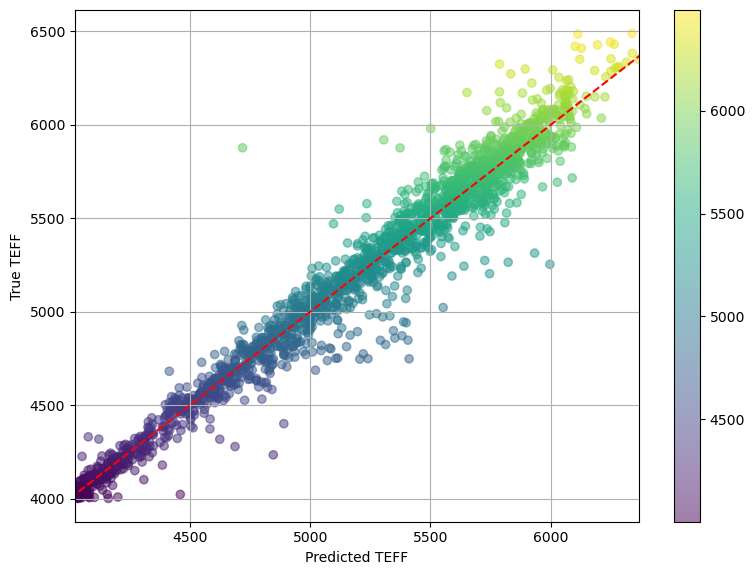

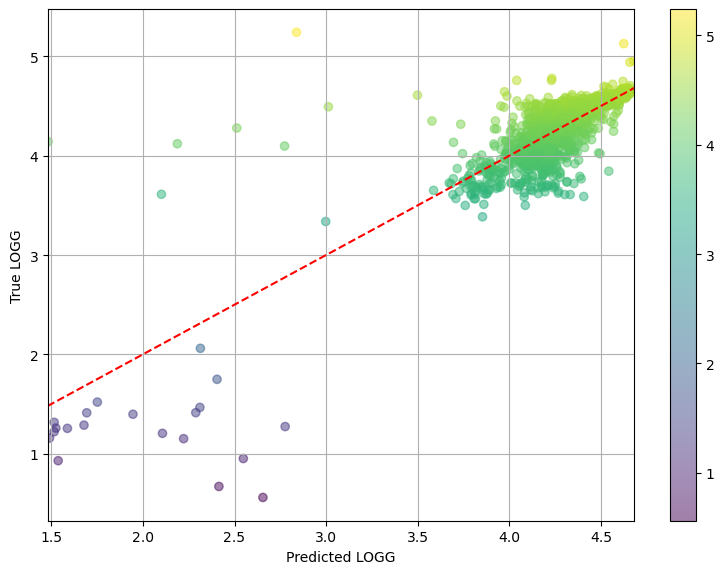

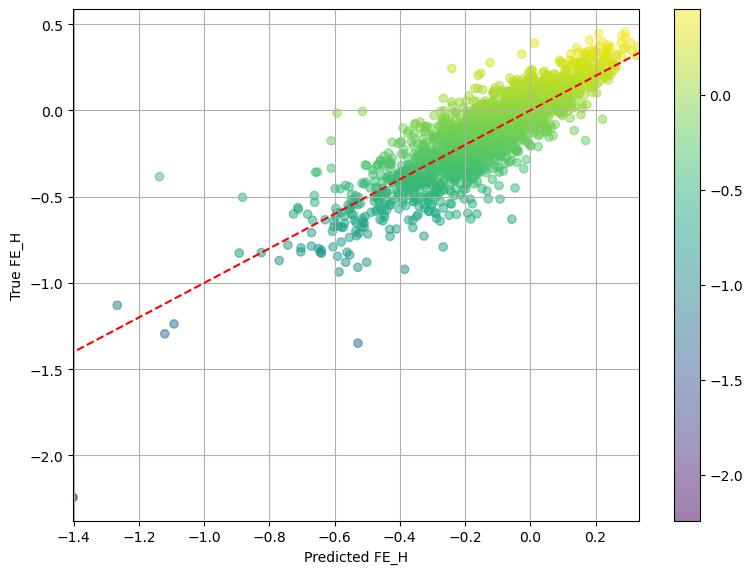

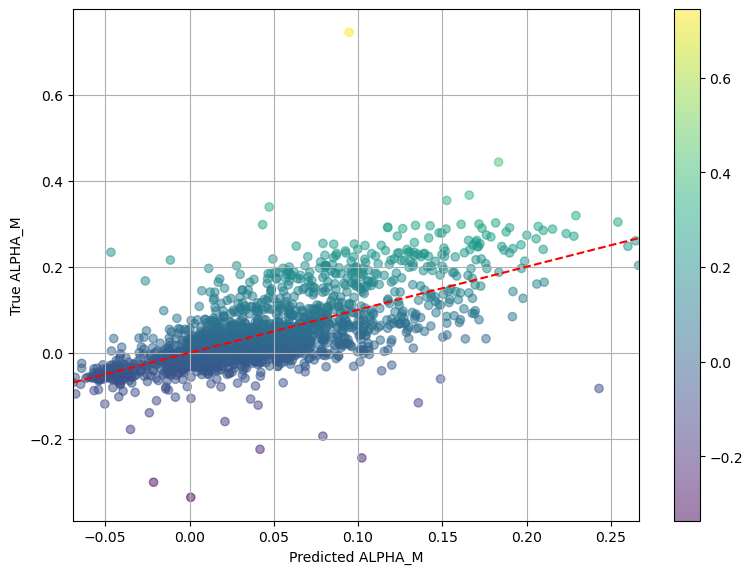

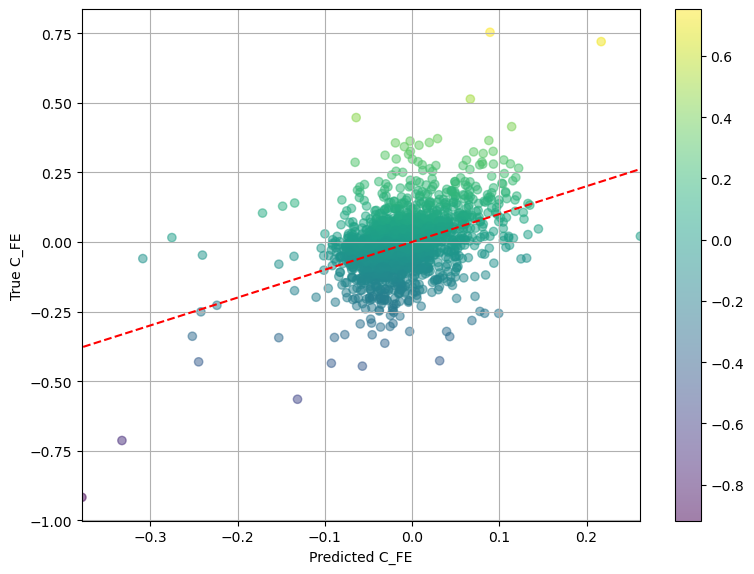

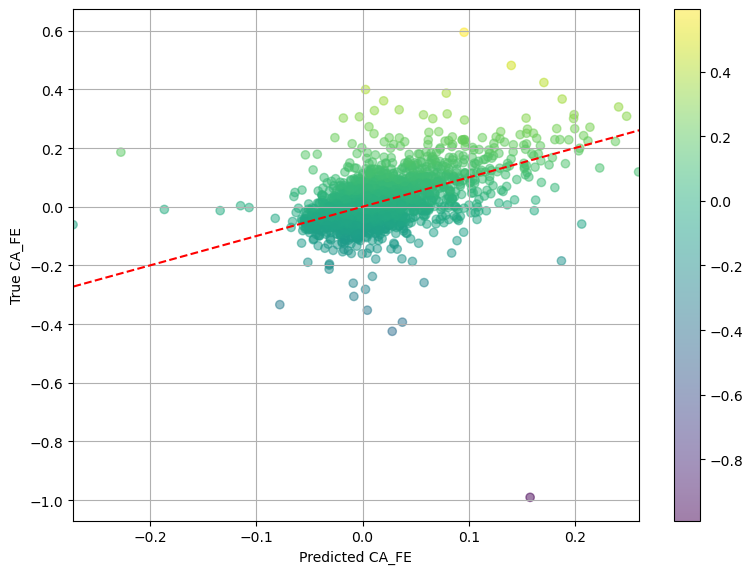

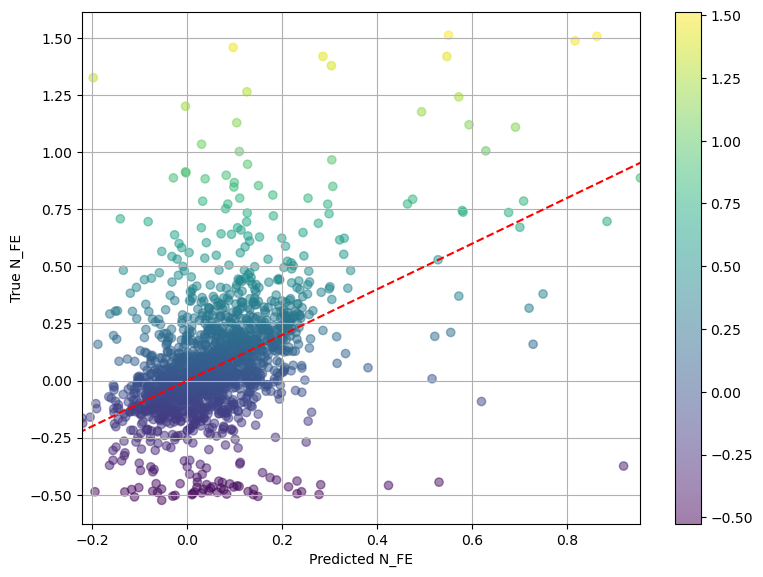

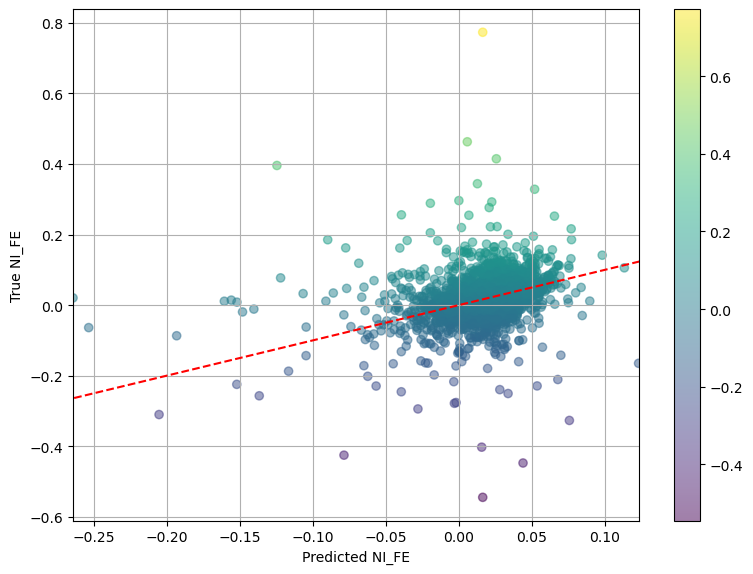

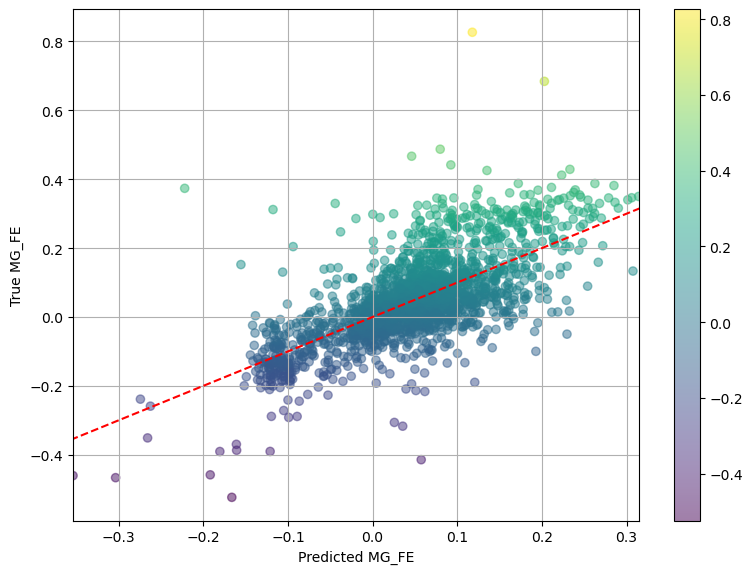

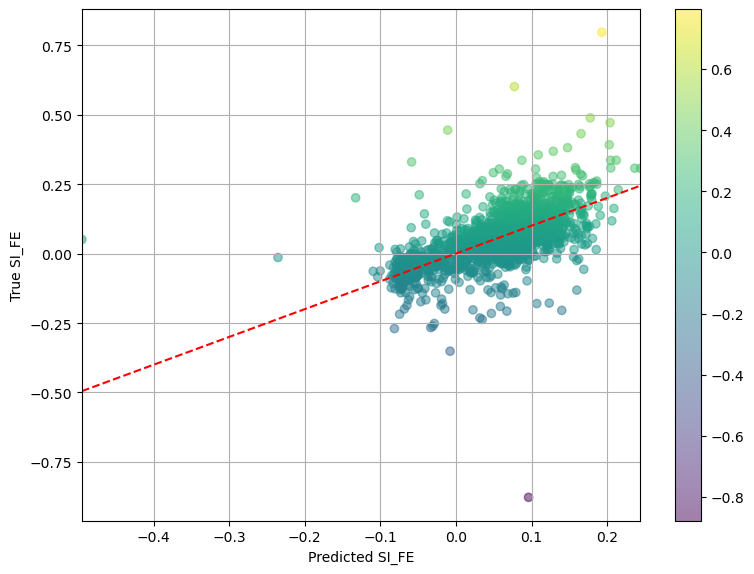

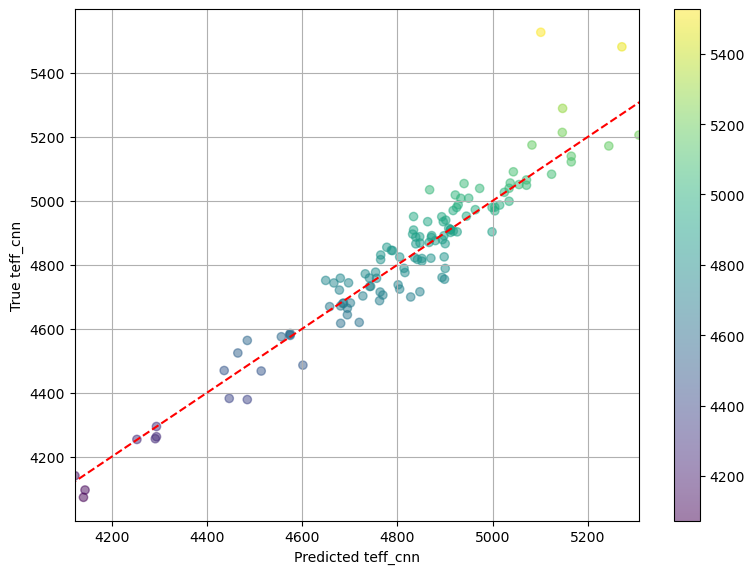

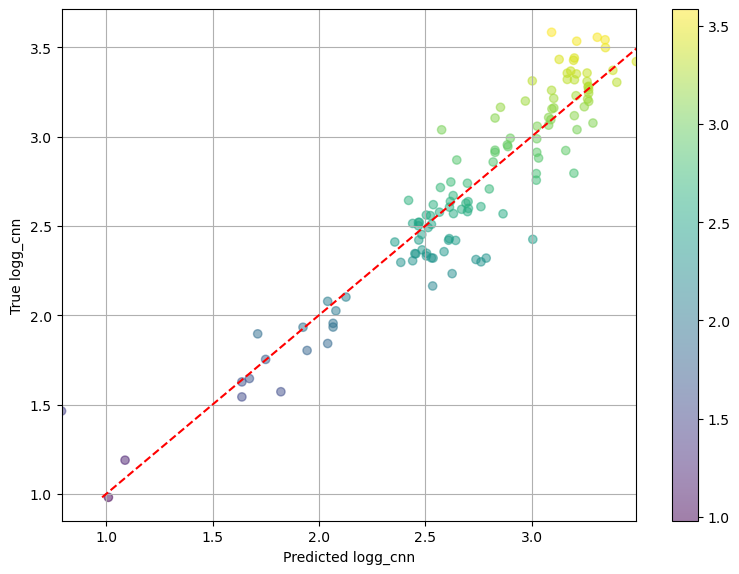

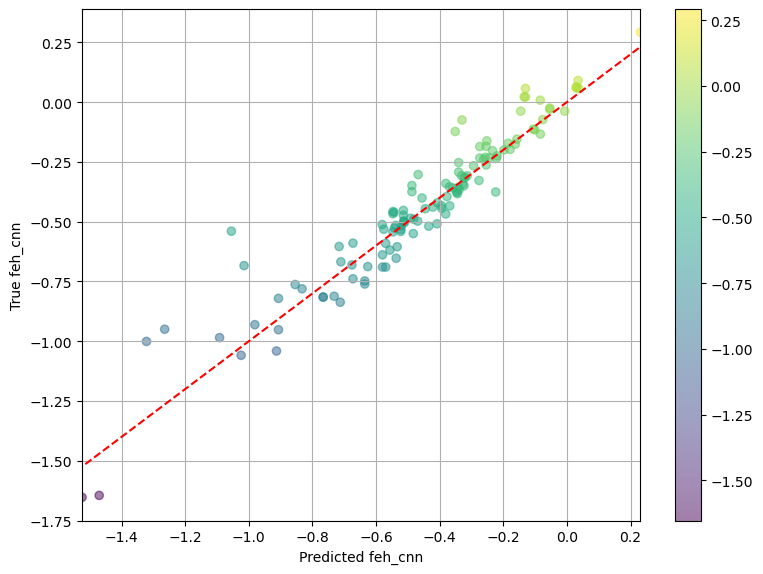

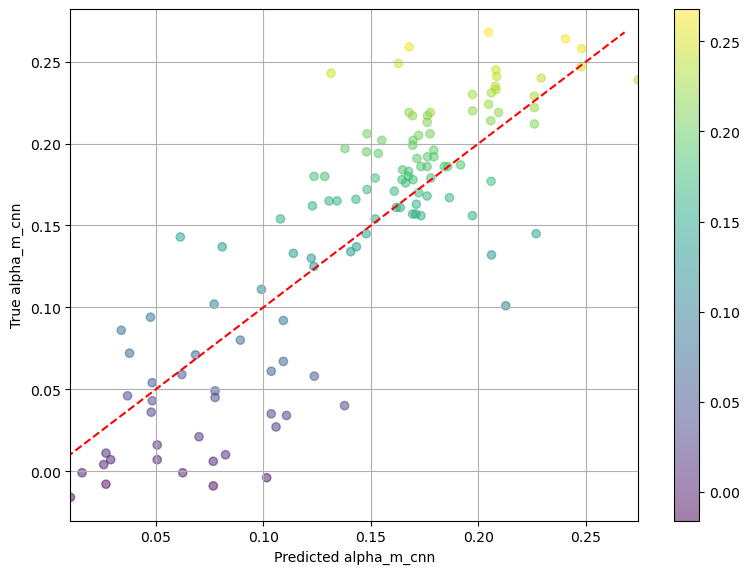

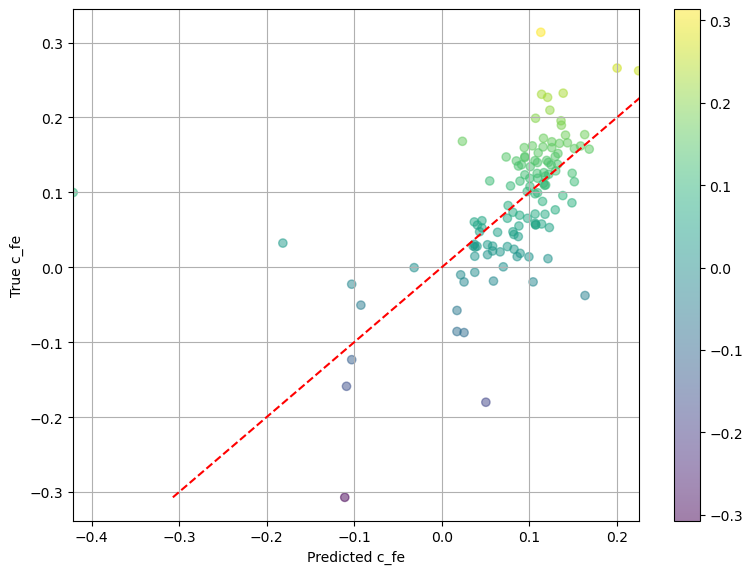

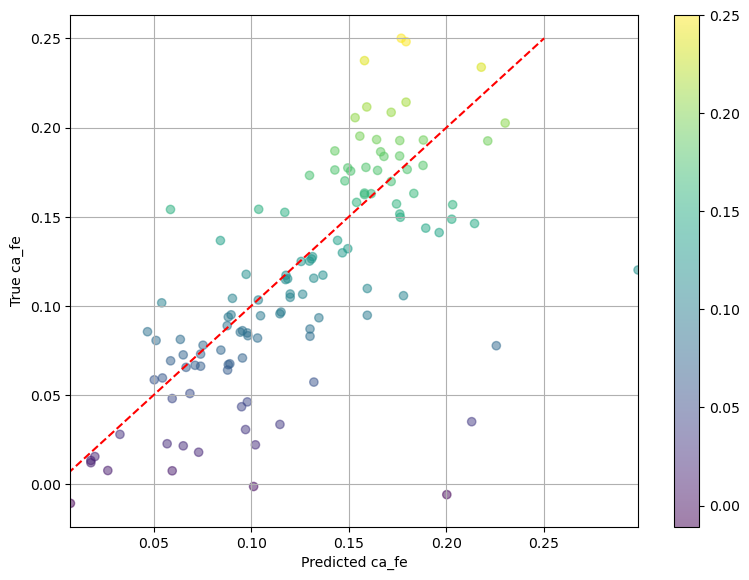

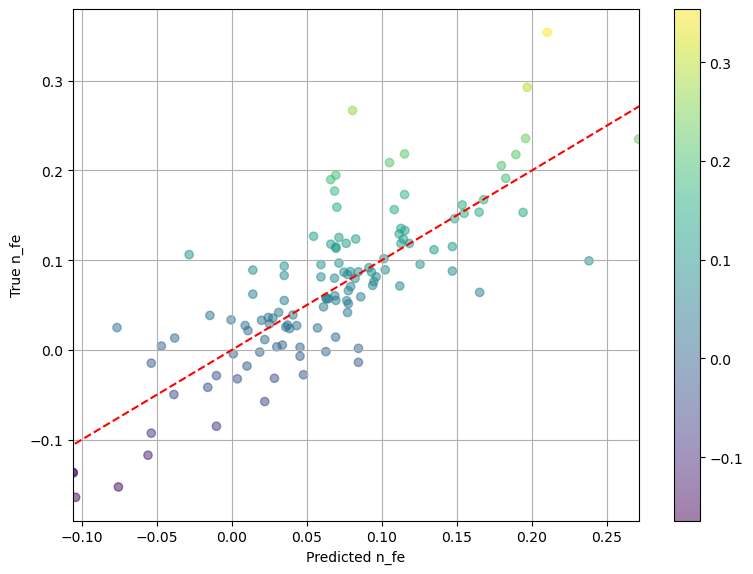

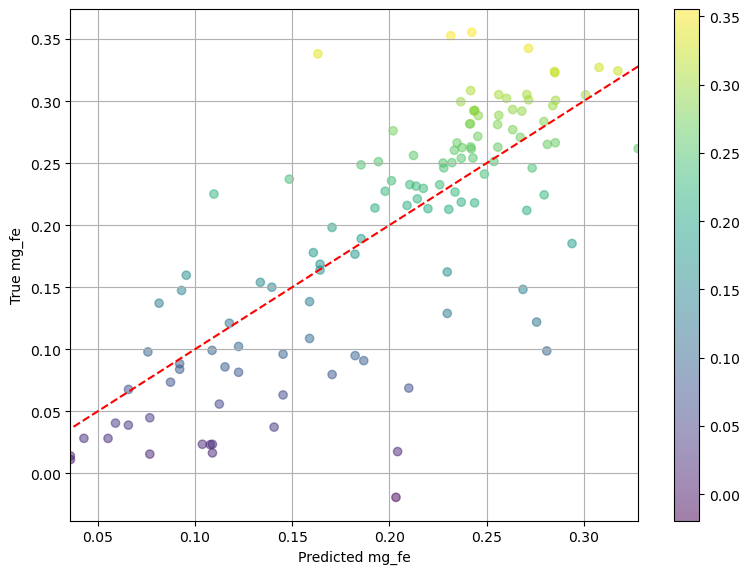

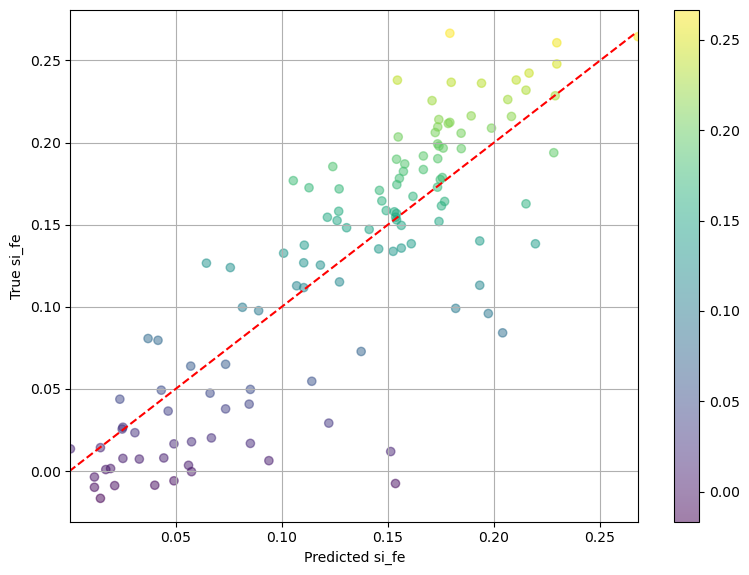

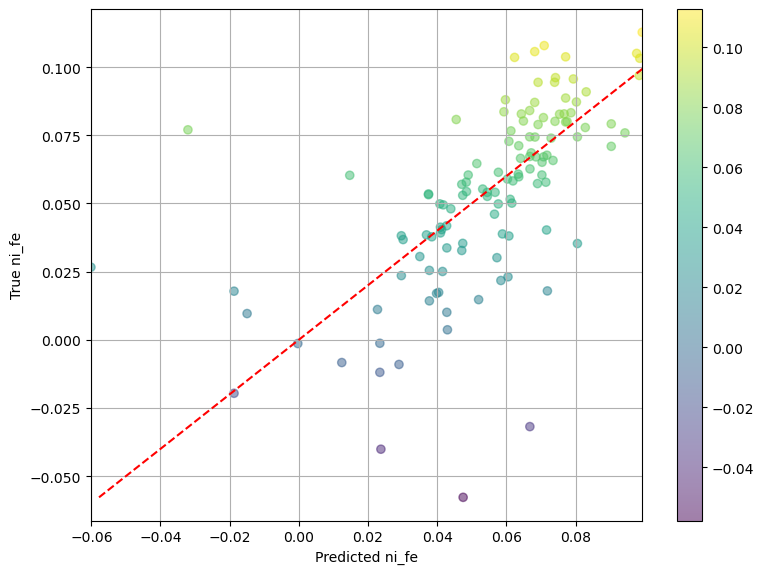

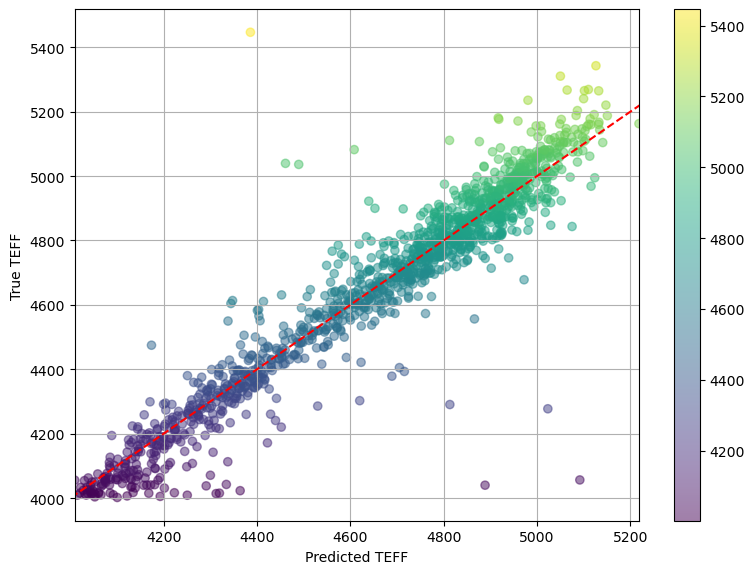

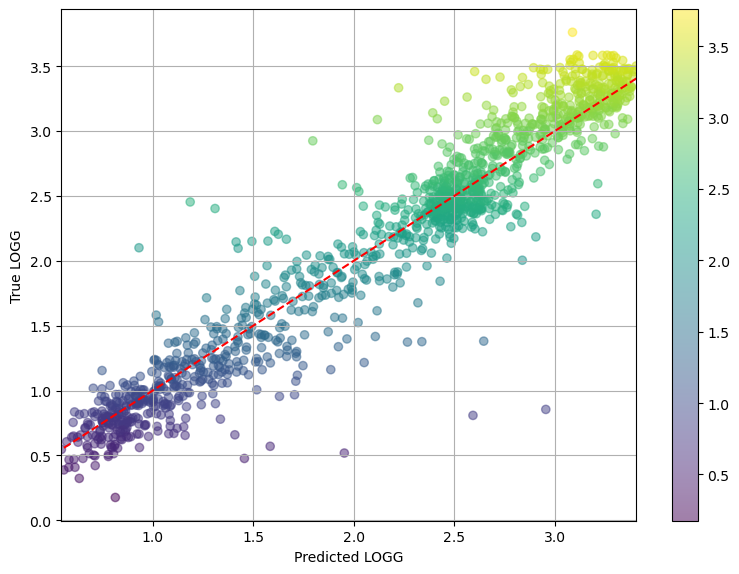

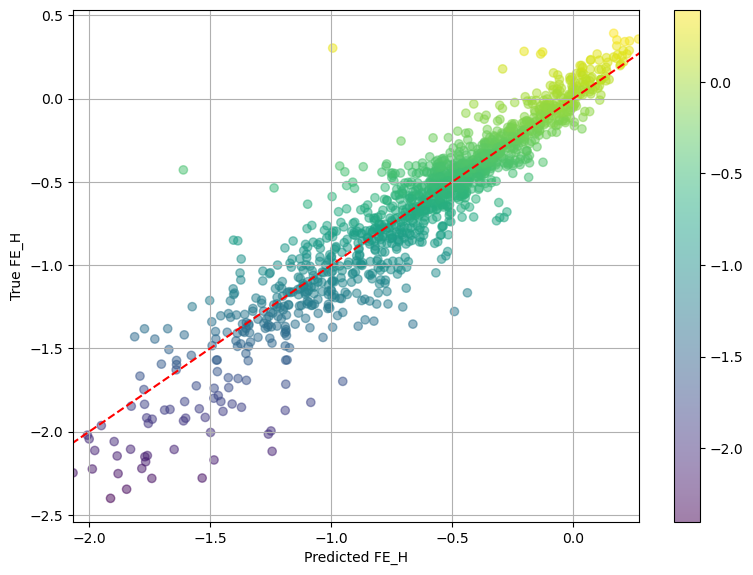

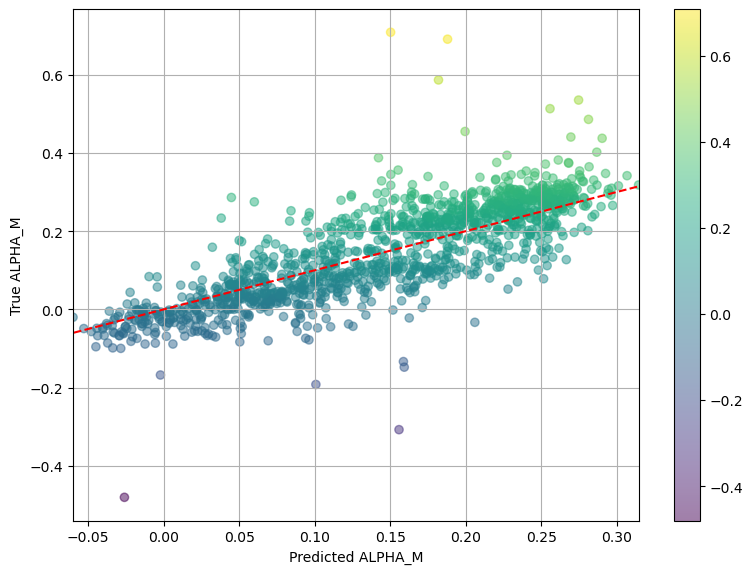

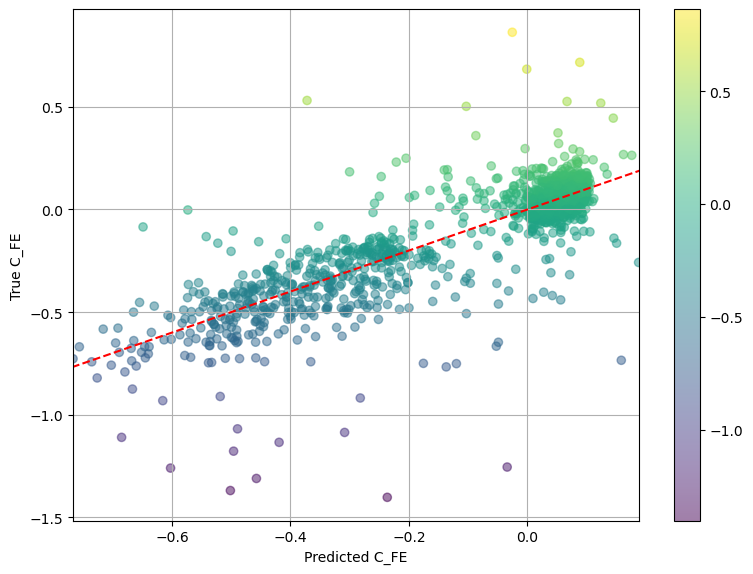

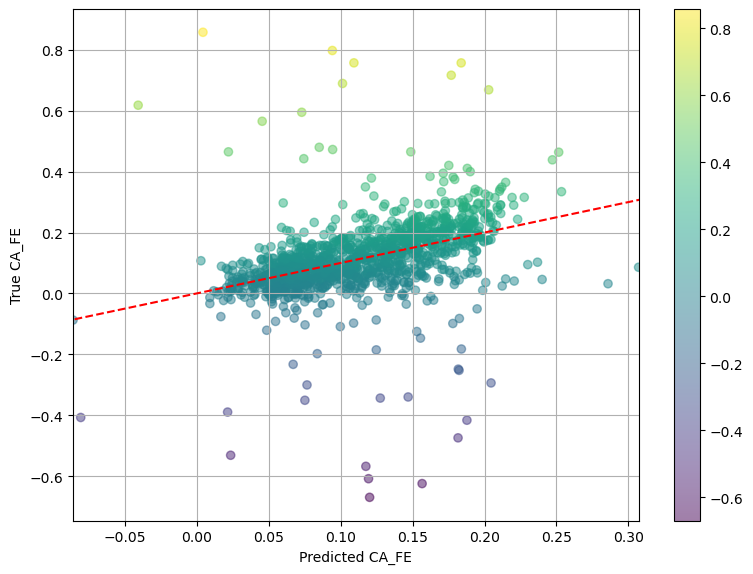

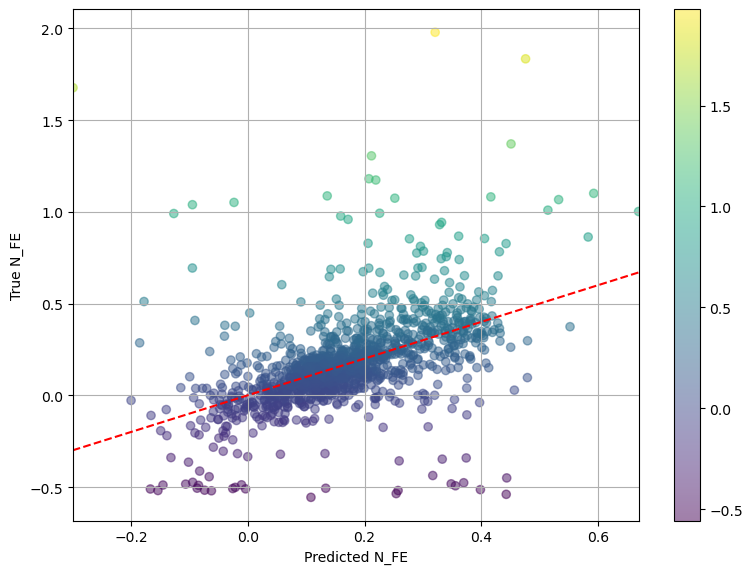

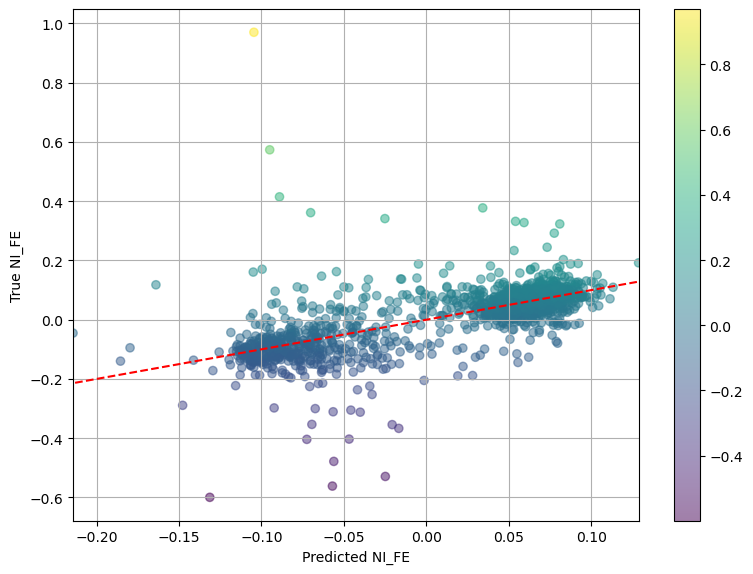

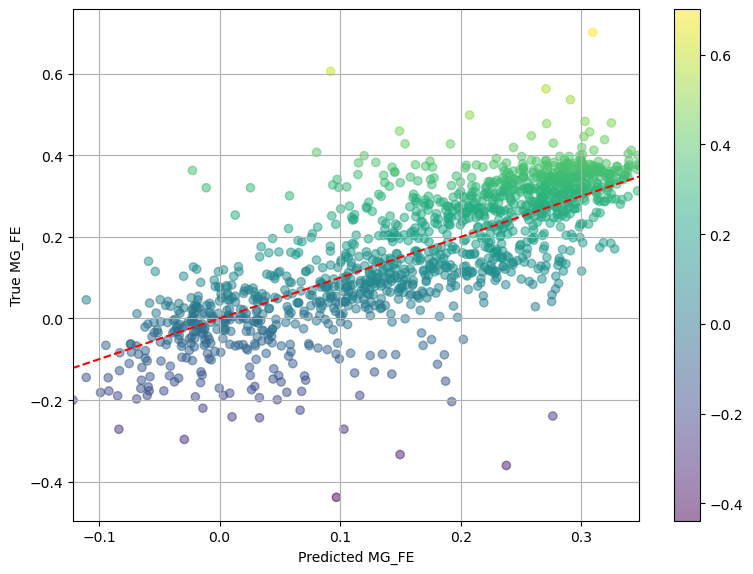

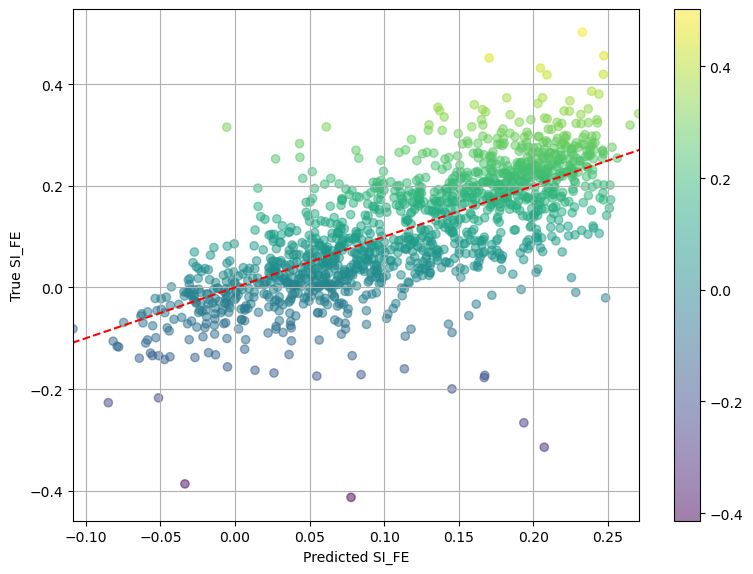

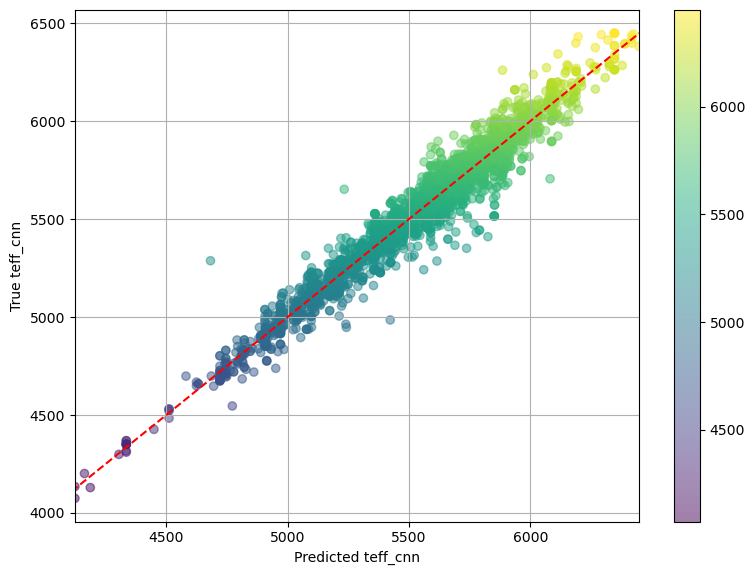

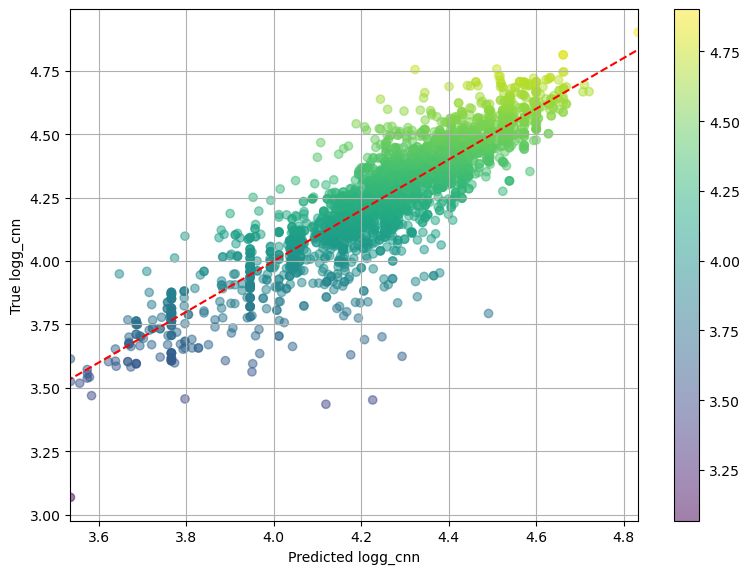

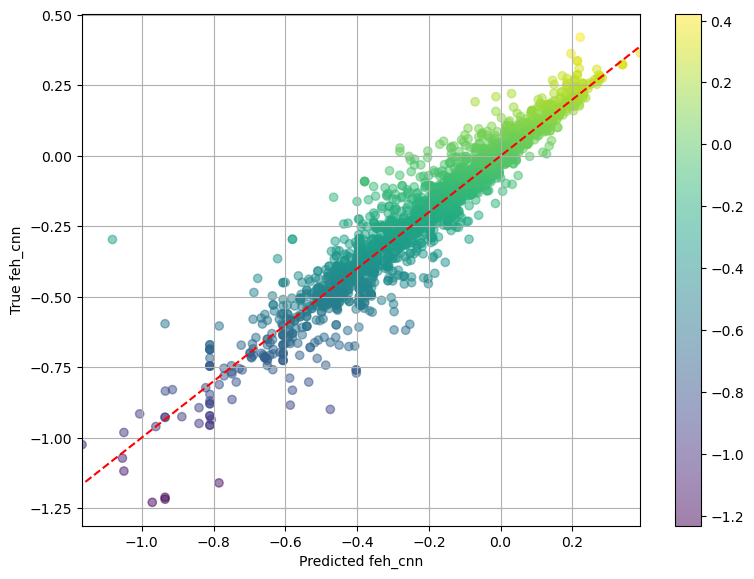

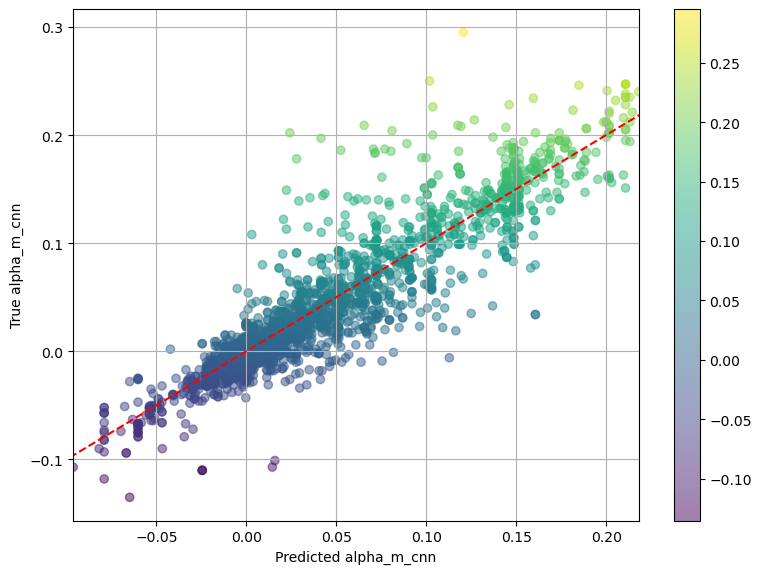

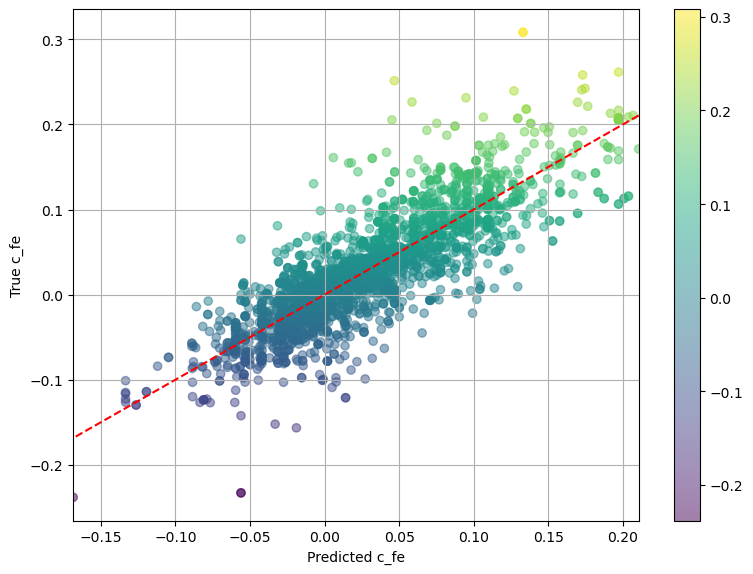

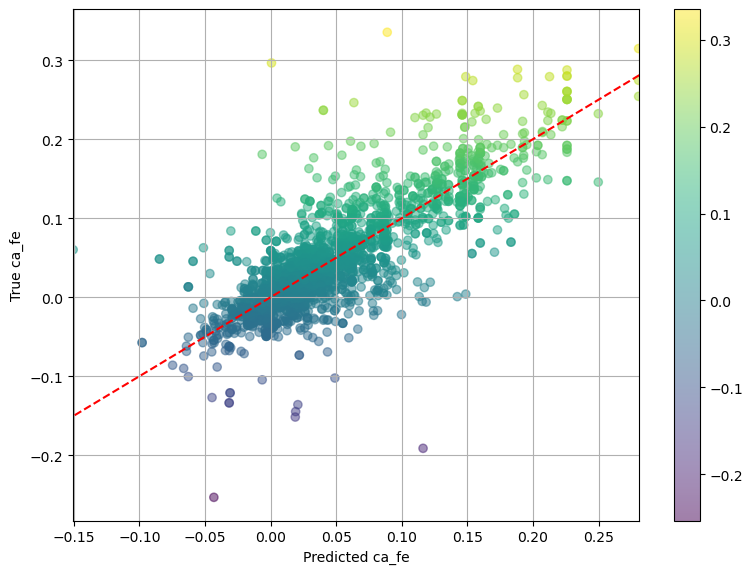

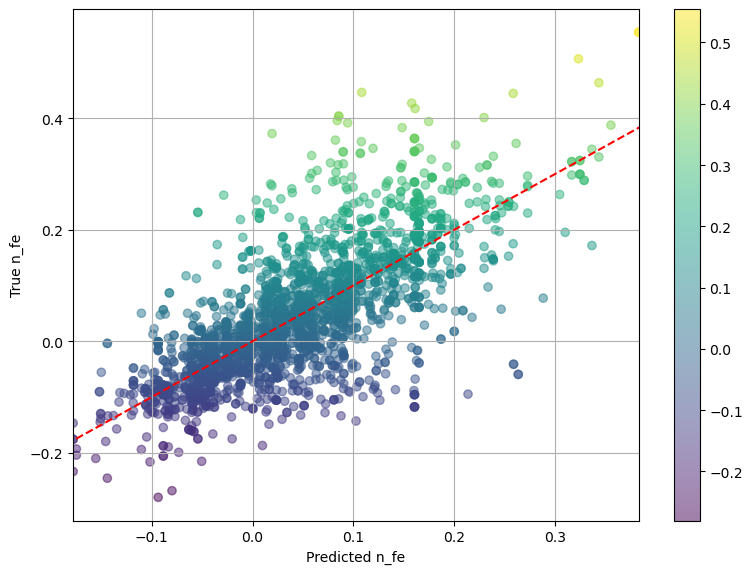

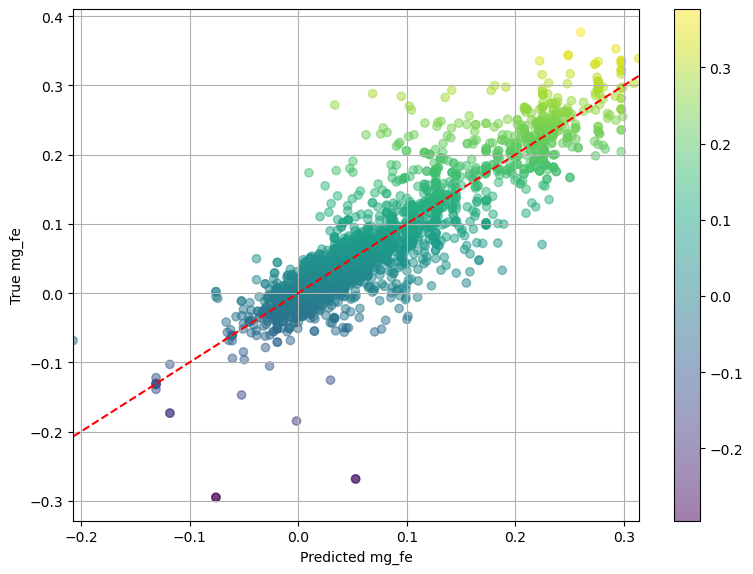

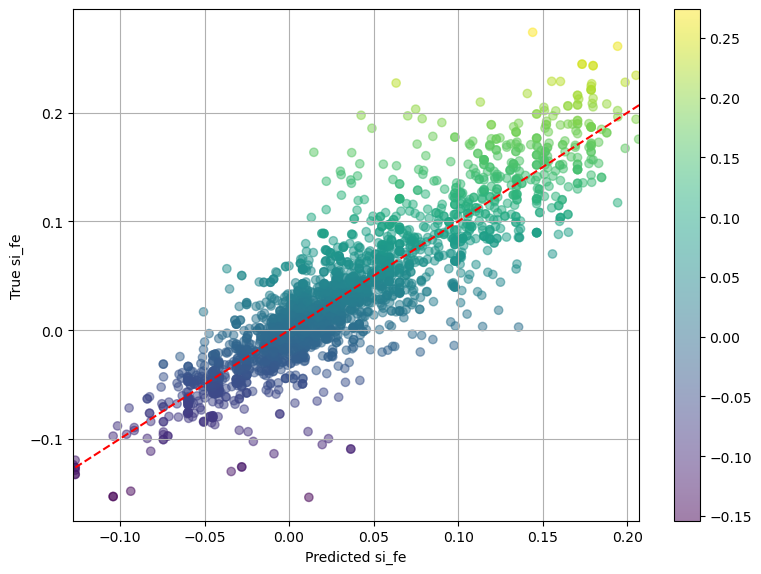

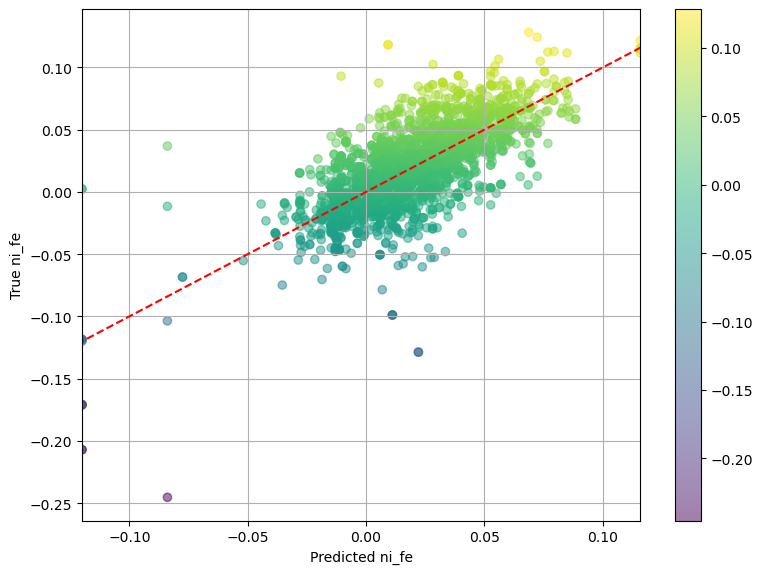

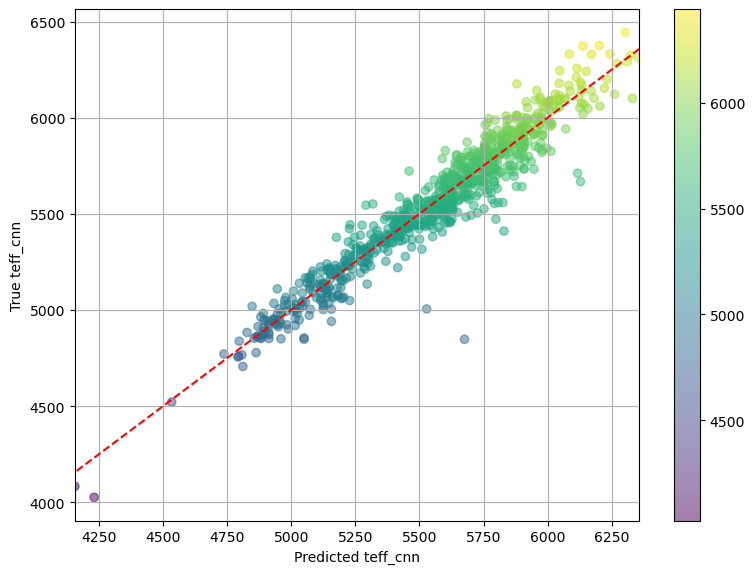

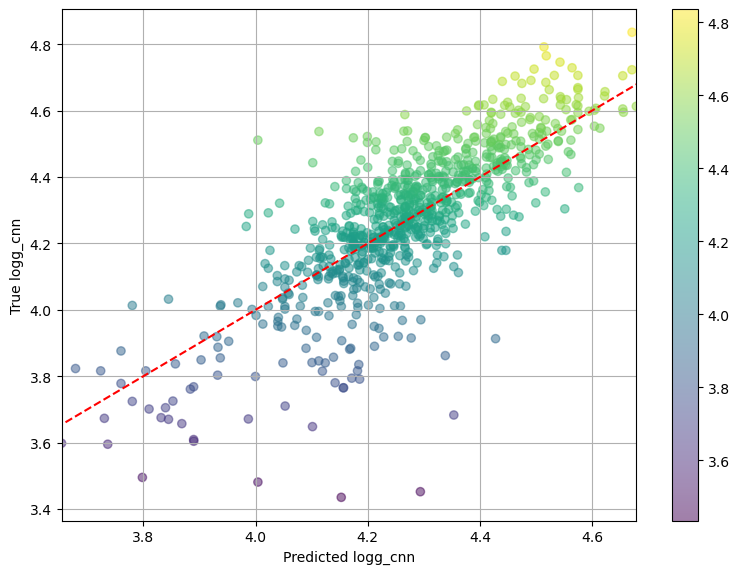

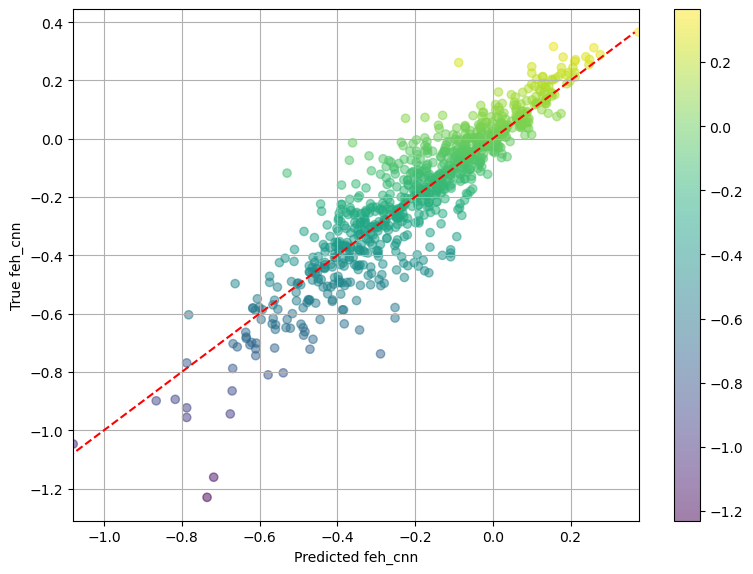

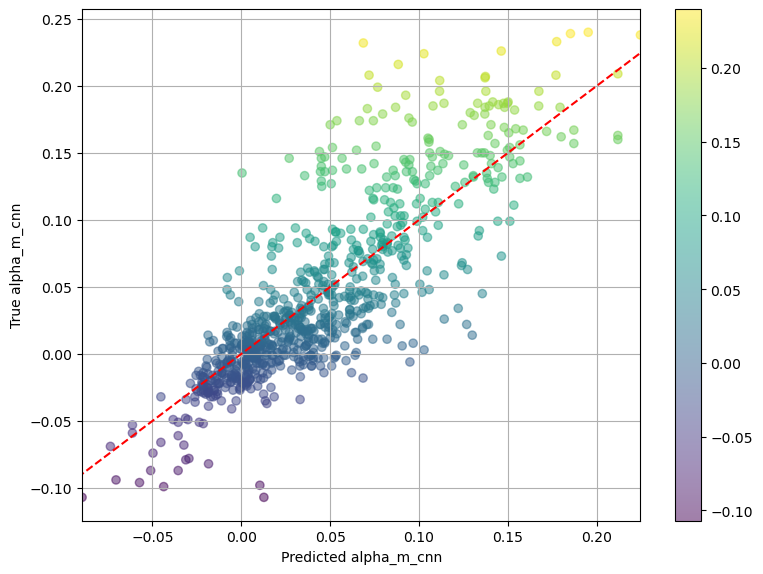

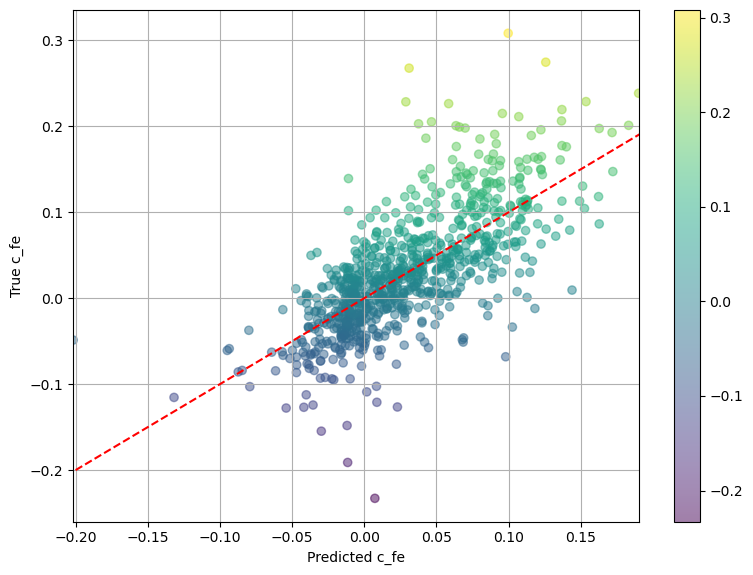

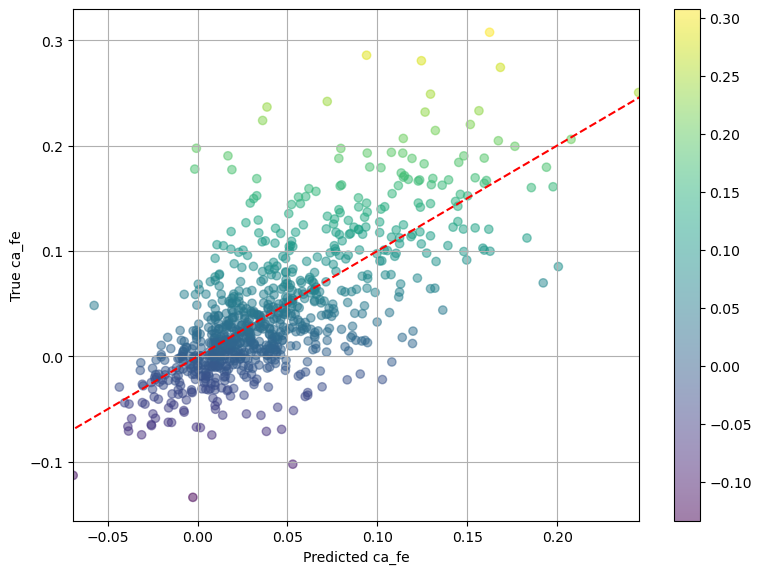

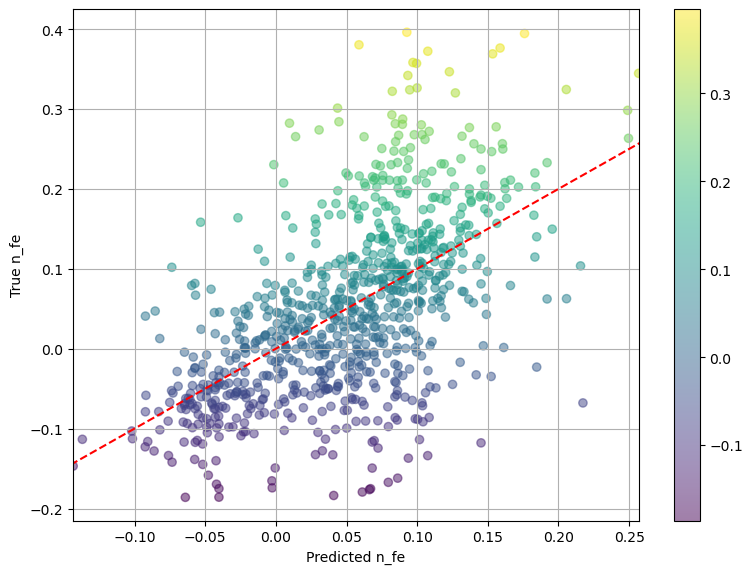

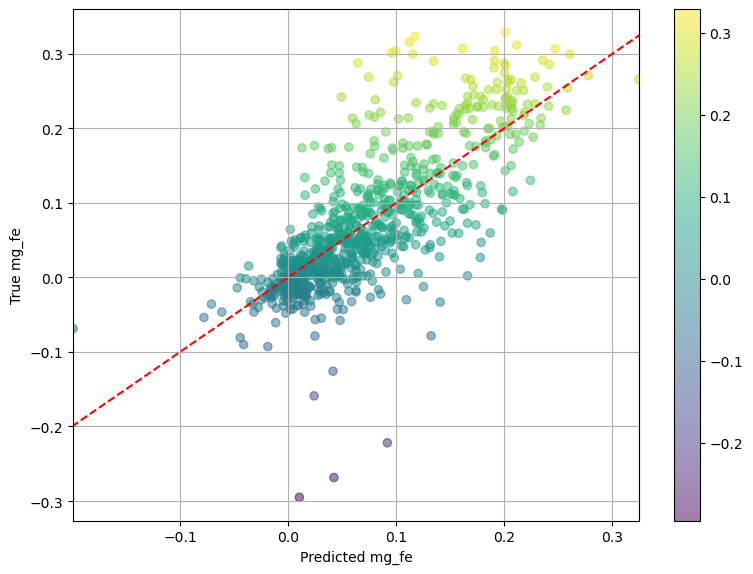

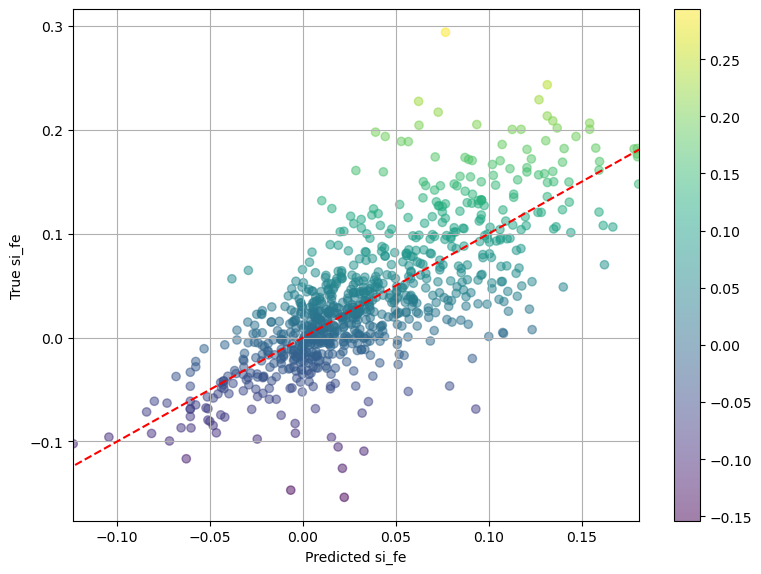

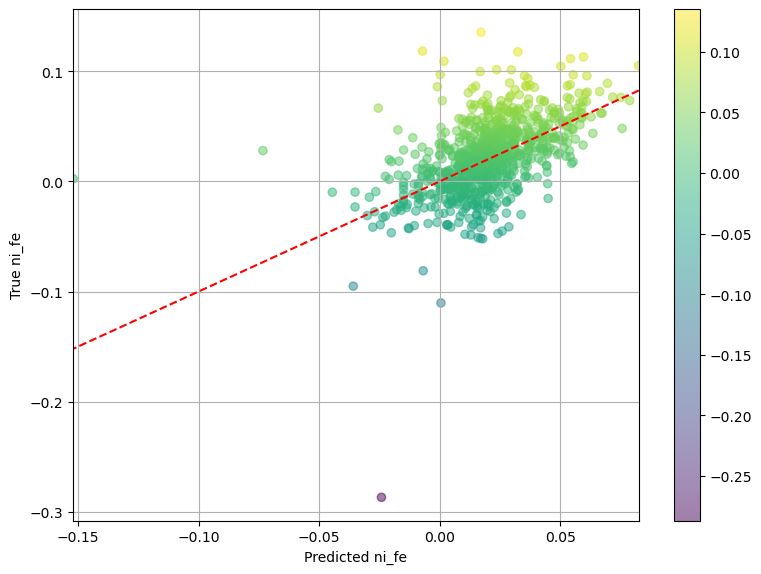

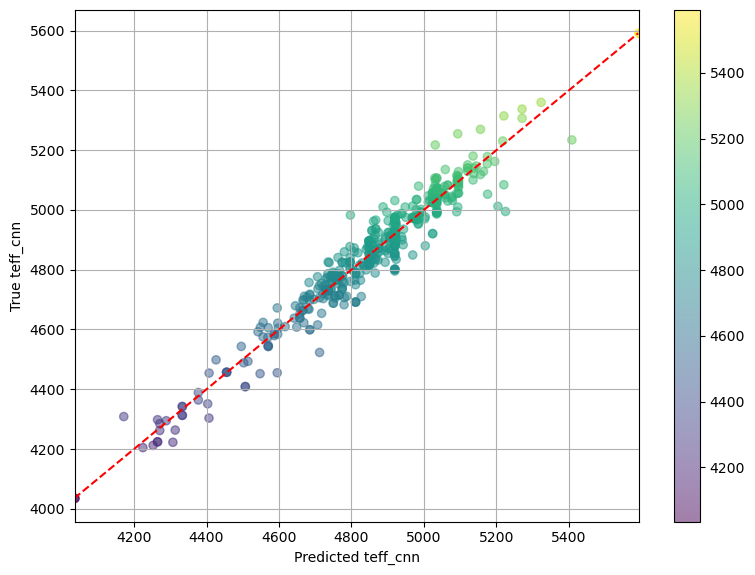

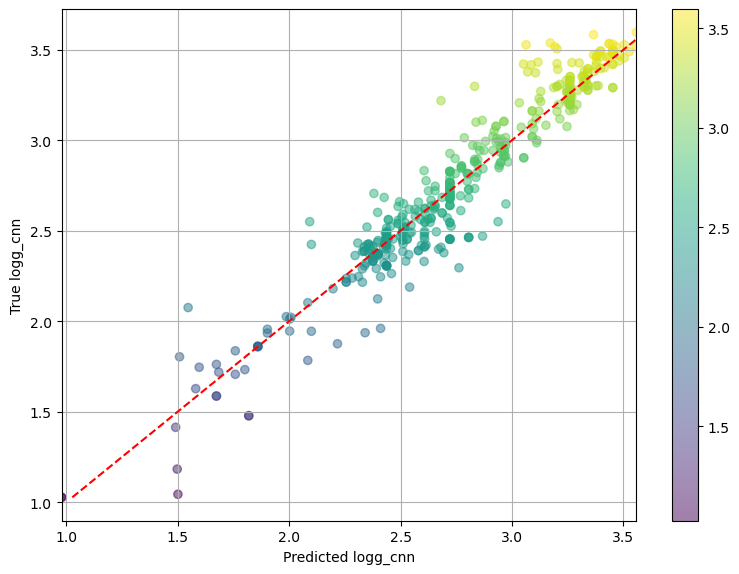

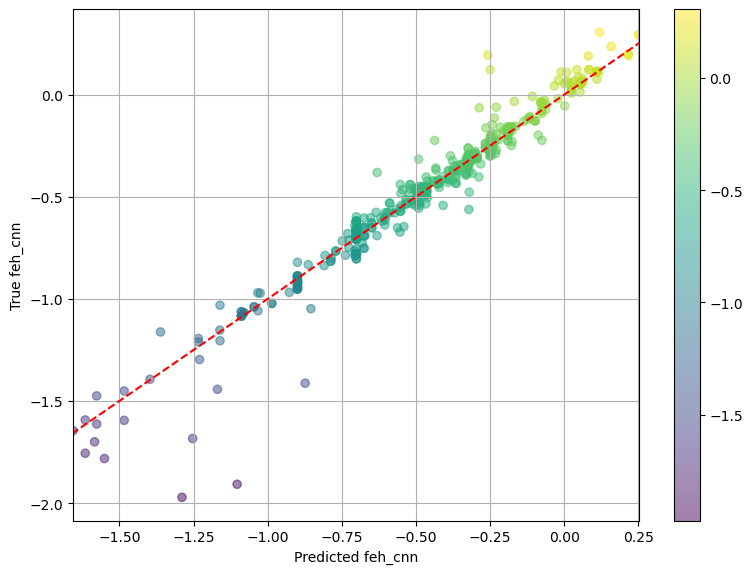

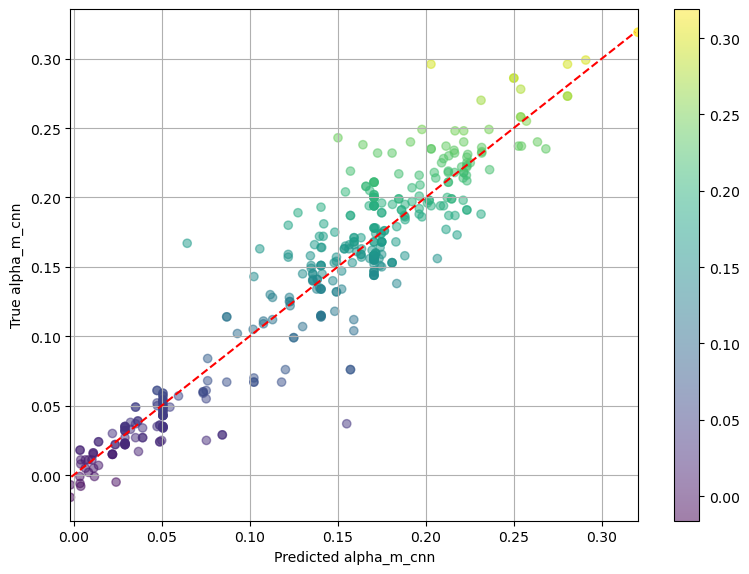

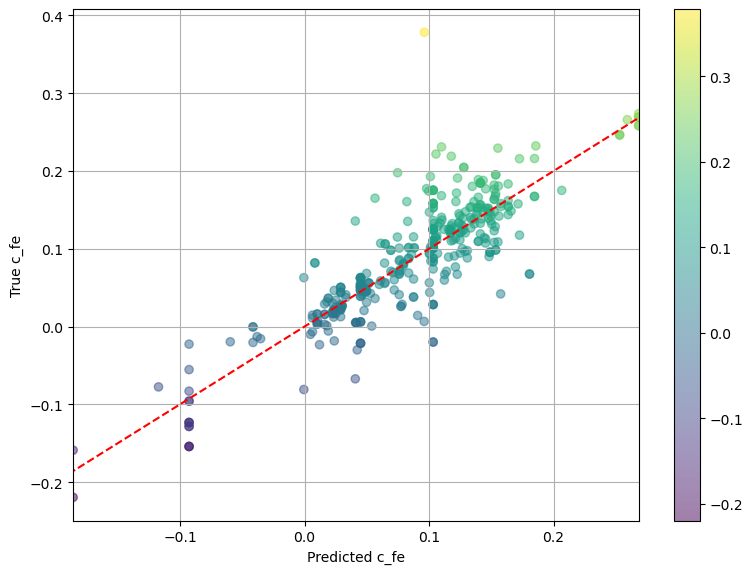

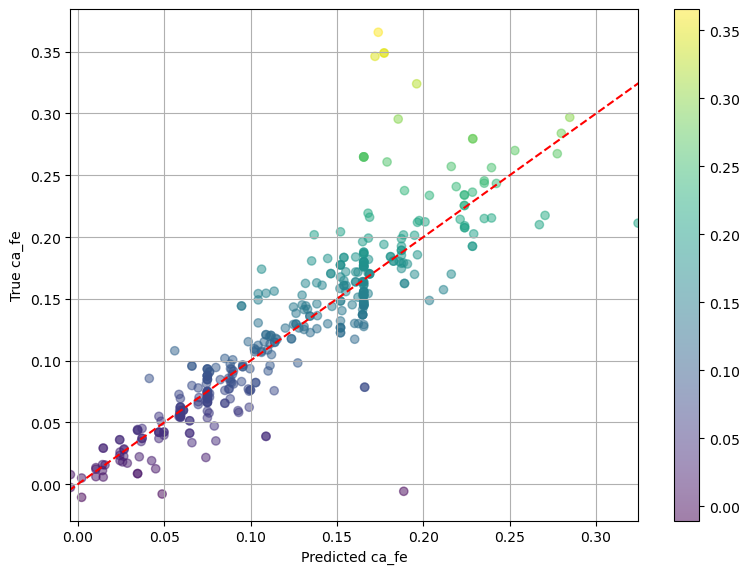

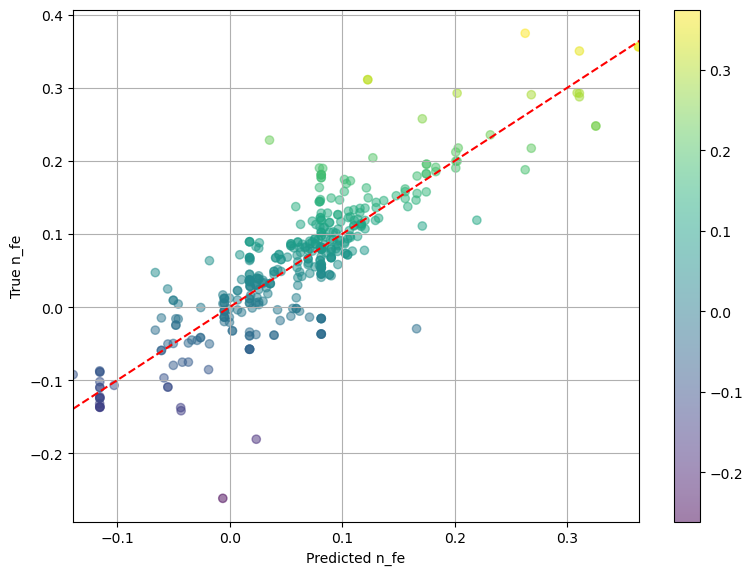

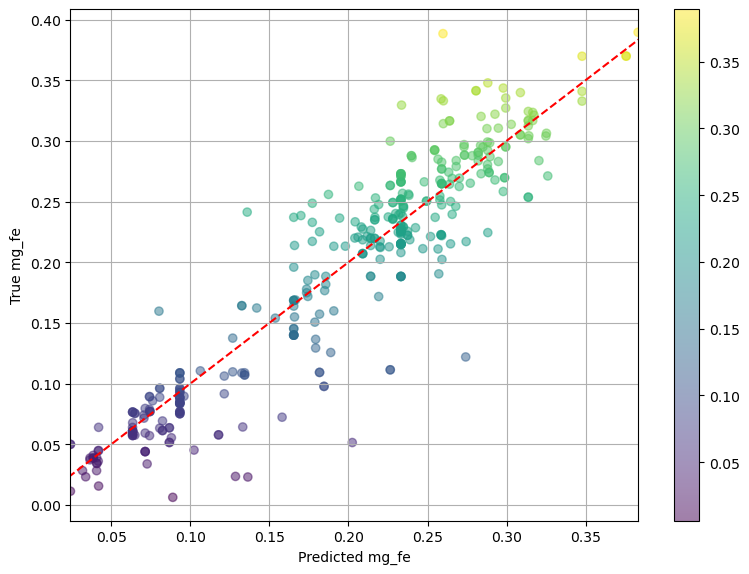

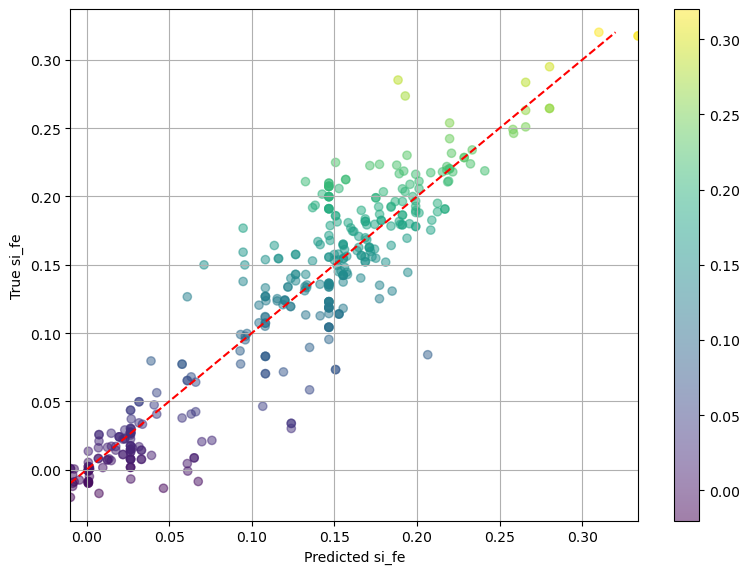

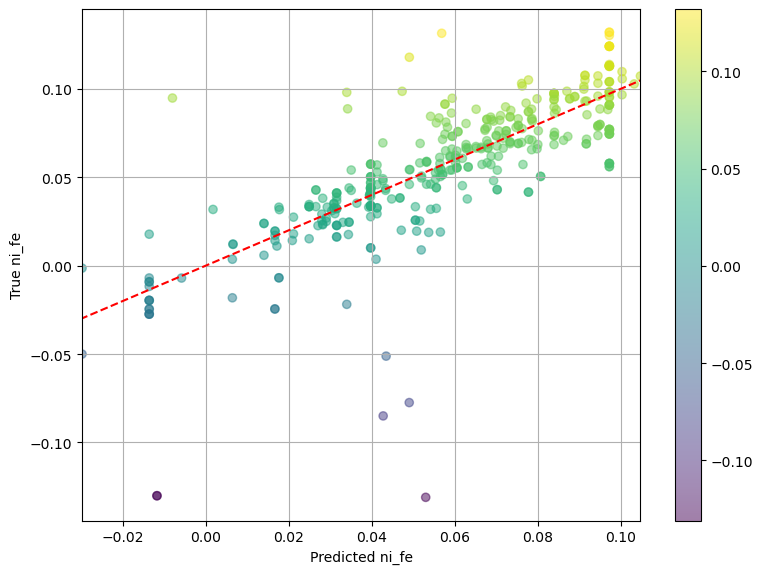

[CV] END ..max_depth=20, max_features=log2, n_estimators=500; total time=   8.1s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   3.4s
[CV] END ..max_depth=30, max_features=log2, n_estimators=800; total time=  13.6s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=500; total time=   5.9s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   2.8s
[CV] END ..max_depth=20, max_features=log2, n_estimators=800; total time=  11.6s
[CV] END max_depth=None, max_features=sqrt, n_estimators=500; total time=   8.7s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=200; total time=   2.3s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   3.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   3.0s
[CV] END ..max_depth=20, max_features=log2, n_estimators=500; total time=   7.5s
[CV] END ..max_depth=30, max_features=log2, n_estimators=500; total time=   7.7s
[CV] END max_depth=None, max

In [105]:
for i in file_names:
    test = i
    df_original = pd.read_csv(f'/home/marcelo/nico/data_Splus_parameters/Filtered_Training_Set/{test}.csv')    
    df_original = preprocess_features(df_original,df_original.iloc[:, 1:67].columns,999)
    df_original = preprocess_features(df_original,df_original.iloc[:, 1:67].columns,9999)
    df_original = preprocess_features(df_original,df_original.iloc[:, 1:67].columns,0)
    for j in df_original.columns[67:]:
        test = test + '_' + str(j)
        AnasCores = df_original.copy(deep=True)
        x_columns = list(AnasCores.iloc[:, 1:67].columns)
        y_column = [j]
        AnasCores = preprocess_features(AnasCores,AnasCores[x_columns+y_column].columns,999)
        AnasCores = preprocess_features(AnasCores,AnasCores[x_columns+y_column].columns,9999)
        AnasCores = preprocess_features(AnasCores,AnasCores[x_columns+y_column].columns,0)
        xtrain = AnasCores[x_columns]
        ytrain = AnasCores[j]
        X_train, X_test, Y_train, Y_test = train_test_split(xtrain, ytrain, test_size=0.2, random_state=11085)
        grid_search = optimize_hyperparameters(X_train,Y_train)
        best_params, best_score = grid_search.best_params_, grid_search.best_score_
        pd.DataFrame([best_params]).to_csv(f'/home/marcelo/nico/data_Splus_parameters/result/best_param_{test}.csv',index=False)
        rf_regressor = RandomForestRegressor(**best_params)
        rf_regressor.fit(X_train, Y_train)
        filename = f'/home/marcelo/nico/data_Splus_parameters/result/{test}.sav'
        joblib.dump(rf_regressor, filename)
        #rf_regressor = joblib.load(filename) this is to load the random forest model
        y_pred = rf_regressor.predict(X_test)
        metalicidad = AnasCores.loc[Y_test.index][y_column]
        y_pred_df = pd.DataFrame(y_pred, columns=y_column)
        plot_regression_results(Y_test, y_pred_df,metalicidad,test)

In [112]:
df = pd.read_csv('/home/marcelo/nico/data_Splus_parameters/result/RF_files.txt',names=['files'])

In [119]:
for i in df['files']:
    print(i)

Apogee-Colors-Dwarfs_ALPHA_M.sav
Apogee-Colors-Dwarfs_Apogee-Colors-Dwarfs_TEFF.sav
Apogee-Colors-Dwarfs_CA_FE.sav
Apogee-Colors-Dwarfs_C_FE.sav
Apogee-Colors-Dwarfs_FE_H.sav
Apogee-Colors-Dwarfs_MG_FE.sav
Apogee-Colors-Dwarfs_N_FE.sav
Apogee-Colors-Dwarfs_NI_FE.sav
Apogee-Colors-Dwarfs_SI_FE.sav
Apogee-Colors-Dwarfs_TEFF_LOGG.sav
Apogee-Colors-Giants_ALPHA_M.sav
Apogee-Colors-Giants_CA_FE.sav
Apogee-Colors-Giants_C_FE.sav
Apogee-Colors-Giants_FE_H.sav
Apogee-Colors-Giants_MG_FE.sav
Apogee-Colors-Giants_N_FE.sav
Apogee-Colors-Giants_NI_FE.sav
Apogee-Colors-Giants_SI_FE.sav
Apogee-Colors-Giants_TEFF_LOGG.sav
Galah-Colors-Dwarfs_ca_fe.sav
Galah-Colors-Dwarfs_c_fe.sav
Galah-Colors-Dwarfs_feh_cnn.sav
Galah-Colors-Dwarfs_logg_cnn.sav
Galah-Colors-Dwarfs_m_cnn.sav
Galah-Colors-Dwarfs_mg_fe.sav
Galah-Colors-Dwarfs_n_fe.sav
Galah-Colors-Dwarfs_ni_fe.sav
Galah-Colors-Dwarfs_si_fe.sav
Galah-Colors-Dwarfs_teff_cnn.sav
Galah-Colors-Giants_ca_fe.sav
Galah-Colors-Giants_c_fe.sav
Galah-Colors-Giants_

In [136]:
test

'LamostMedium-Colors-Giants_teff_cnn_logg_cnn_feh_cnn_alpha_m_cnn_c_fe_ca_fe_n_fe_mg_fe_si_fe_ni_fe'

In [134]:
pd.read_csv('/home/marcelo/nico/SplusData/short_splusAll_9Filters_modified.csv')

,splus_oid,#Field,Ra,Dec,IDRef,NMG,mag_psf_u,mag_psf_J0378,mag_psf_J0395,mag_psf_J0410,mag_psf_J0430,mag_psf_g,mag_psf_J0515,mag_psf_r,mag_psf_J0660,mag_psf_i,mag_psf_J0861,mag_psf_z
0,1,HYDRA-0011_000000005,150.194977,-24.592108,10,10,20.43267,-999.00000,19.86467,-999.00000,20.06167,19.76667,19.71667,19.36067,19.40067,19.24467,19.31167,19.18367
1,2,HYDRA-0011_000000030,150.183609,-24.589680,10,12,19.62538,19.36938,19.54638,18.92646,18.67946,18.40346,18.29846,17.85970,17.80078,17.67080,17.62093,17.59193
2,3,HYDRA-0011_000000042,149.957794,-24.588993,10,12,18.95029,18.81129,18.74629,18.15370,17.99870,17.72670,17.52570,17.24526,17.20626,17.11527,17.10416,17.13216
3,4,HYDRA-0011_000000045,149.967041,-24.591400,10,12,18.46829,18.61929,18.23829,17.55570,17.15270,17.94070,16.33870,15.78526,15.68526,15.55027,15.53916,15.50316
4,5,HYDRA-0011_000000049,150.534393,-24.589628,10,12,18.15267,18.06767,17.77167,17.22967,17.13467,17.68667,16.50867,16.20967,17.48467,17.19217,15.96467,15.90867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11219823,11219824,SPLUS-s46s40_000019479,341.906708,-59.911304,1210,10,15.74330,15.52730,15.25730,14.38172,14.13672,13.45872,13.38272,12.58063,12.46463,-999.00000,12.15818,-999.00000
11219824,11219825,SPLUS-s46s40_000019781,341.161926,-58.965340,1210,10,14.99280,14.76880,14.44680,13.80987,13.64087,13.09306,12.92106,12.42387,12.35689,-999.00000,12.13903,-999.00000
11219825,11219826,SPLUS-s46s40_000019820,341.899689,-58.876694,1210,11,19.65516,19.25016,19.11016,18.78703,18.71903,18.49103,18.29703,18.00562,17.96862,17.87928,17.87840,-999.00000
11219826,11219827,SPLUS-s46s40_000019887,340.503815,-59.253468,1210,10,17.64677,17.08577,16.64877,16.05146,15.99846,14.74746,14.45846,13.46394,12.99294,-999.00000,11.52252,-999.00000


In [120]:
modelo_rf = joblib.load(f'/home/marcelo/nico/data_Splus_parameters/result/{i}')

In [121]:
modelo_rf

RandomForestRegressor(max_features='log2', n_estimators=200)